In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("amananandrai/ag-news-classification-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ag-news-classification-dataset' dataset.
Path to dataset files: /kaggle/input/ag-news-classification-dataset


In [2]:
ls /kaggle/input/ag-news-classification-dataset

test.csv  train.csv


##Install & Import libraries
Installing required packages (nltk for preprocessing, sklearn for the classic models, tensorflow for the bonus neural network) and importing everything we'll need.

##

In [3]:
!pip install wordcloud -q

import pandas as pd
import numpy as np
import re
import string
import glob
import os
from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
from sklearn.model_selection import GridSearchCV

import matplotlib.pyplot as plt
from wordcloud import WordCloud

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense, Dropout
from tensorflow.keras.utils import to_categorical

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

STOPWORDS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


##Load the dataset
`train.csv` and `test.csv` DO contain a header row. According to the dataset documentation, the columns are: `Class Index` (1 to 4), `Title`, `Description`.

Label mapping from the original `classes.txt`:
1 = World | 2 = Sports | 3 = Business | 4 = Sci/Tech

In [4]:
csv_files = glob.glob(os.path.join(path, "**", "*.csv"), recursive=True)
print("Found CSV files:", csv_files)

train_path = [f for f in csv_files if 'train' in f.lower()][0]
test_path = [f for f in csv_files if 'test' in f.lower()][0]

col_names = ['class_index', 'title', 'description']
# The CSV files contain a header row ('Class Index, Title, Description'),
# so we read it normally and just rename the columns to our own convention.
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

train_df.columns = col_names
test_df.columns = col_names

label_map = {1: 'World', 2: 'Sports', 3: 'Business', 4: 'Sci/Tech'}
train_df['category'] = train_df['class_index'].map(label_map)
test_df['category'] = test_df['class_index'].map(label_map)

# Combine title + description into a single text field (usually boosts accuracy vs. description alone)
train_df['text'] = train_df['title'] + " " + train_df['description']
test_df['text'] = test_df['title'] + " " + test_df['description']

print("Train shape:", train_df.shape, "| Test shape:", test_df.shape)
print(train_df['category'].value_counts())
train_df.head()

Found CSV files: ['/kaggle/input/ag-news-classification-dataset/train.csv', '/kaggle/input/ag-news-classification-dataset/test.csv']
Train shape: (120000, 5) | Test shape: (7600, 5)
category
Business    30000
Sci/Tech    30000
Sports      30000
World       30000
Name: count, dtype: int64


,class_index,title,description,category,text
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli...",Business,Wall St. Bears Claw Back Into the Black (Reute...
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...,Business,Carlyle Looks Toward Commercial Aerospace (Reu...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...,Business,Oil and Economy Cloud Stocks' Outlook (Reuters...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...,Business,Iraq Halts Oil Exports from Main Southern Pipe...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco...",Business,"Oil prices soar to all-time record, posing new..."


##Text preprocessing (tokenization, stopword removal, lemmatization)
Preprocessing steps:
- Lowercase the text
- Remove digits and punctuation
- Tokenization using `nltk.word_tokenize`
- Remove stopwords
- Lemmatization to reduce each word to its base form (more accurate than simple stemming)

The dataset has 127,600 rows and each text is relatively short (title + description), so this step takes a reasonable amount of time.

In [5]:
def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'<.*?>', ' ', text)                # remove HTML tags
    text = re.sub(r'http\S+|www\S+', ' ', text)       # remove URLs
    text = re.sub(r'[^a-z\s]', ' ', text)              # remove punctuation & digits
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in STOPWORDS and len(w) > 2]
    return " ".join(tokens)

train_df['clean_text'] = train_df['text'].apply(preprocess_text)
test_df['clean_text'] = test_df['text'].apply(preprocess_text)

train_df[['text', 'clean_text']].head()

,text,clean_text
0,Wall St. Bears Claw Back Into the Black (Reute...,wall bear claw back black reuters reuters shor...
1,Carlyle Looks Toward Commercial Aerospace (Reu...,carlyle look toward commercial aerospace reute...
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,oil economy cloud stock outlook reuters reuter...
3,Iraq Halts Oil Exports from Main Southern Pipe...,iraq halt oil export main southern pipeline re...
4,"Oil prices soar to all-time record, posing new...",oil price soar time record posing new menace e...


##Train / validation split

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    train_df['clean_text'], train_df['category'],
    test_size=0.1, random_state=42, stratify=train_df['category']
)

X_test = test_df['clean_text']
y_test = test_df['category']

print("Train:", X_train.shape, "| Val:", X_val.shape, "| Test:", X_test.shape)

Train: (108000,) | Val: (12000,) | Test: (7600,)


##Vectorize text using TF-IDF
We use `sublinear_tf=True` (dampens the effect of words that repeat a lot within the same article) and `ngram_range=(1,2)` to capture short phrases like "stock market", not just single words. The data is fairly clean, so we don't need as large a `max_features` as in Task 1.

In [7]:
vectorizer = TfidfVectorizer(max_features=40000, ngram_range=(1, 2), sublinear_tf=True)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)

print(X_train_tfidf.shape)

(108000, 40000)


##Train the main classifier (Linear SVM)
Why SVM here specifically?
- The data is clean, perfectly balanced (30k per class), and fairly large (108k train rows) — this is exactly the setting where `LinearSVC` typically outperforms Logistic Regression and Random Forest on high-dimensional sparse TF-IDF text features.
- `Random Forest` tends to be weaker here since it isn't well suited to sparse high-dimensional features like TF-IDF, and takes much longer to train with no real benefit.
- A simple `GridSearchCV` is used to pick the best value of `C`.

In [8]:
param_grid = {'C': [0.1, 0.5, 1, 2]}
svm_base = LinearSVC(max_iter=5000)

grid = GridSearchCV(svm_base, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid.fit(X_train_tfidf, y_train)

print("Best C:", grid.best_params_, "| Best CV accuracy:", grid.best_score_)

svm_model = grid.best_estimator_
y_val_pred = svm_model.predict(X_val_tfidf)
print("\nValidation Accuracy:", accuracy_score(y_val, y_val_pred))

Best C: {'C': 0.5} | Best CV accuracy: 0.9177407407407406

Validation Accuracy: 0.9241666666666667


##Evaluate the SVM on the test set

=== Linear SVM (Test Set) ===
Accuracy: 0.9198684210526316
              precision    recall  f1-score   support

    Business       0.89      0.88      0.89      1900
    Sci/Tech       0.90      0.91      0.90      1900
      Sports       0.96      0.98      0.97      1900
       World       0.93      0.91      0.92      1900

    accuracy                           0.92      7600
   macro avg       0.92      0.92      0.92      7600
weighted avg       0.92      0.92      0.92      7600



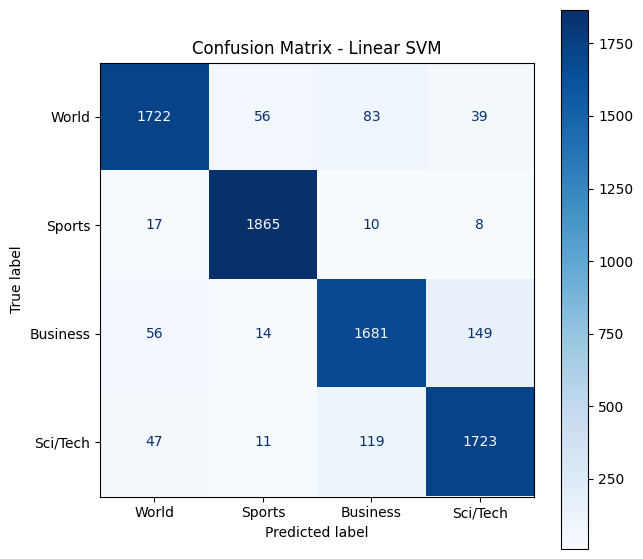

In [9]:
y_pred_svm = svm_model.predict(X_test_tfidf)

print("=== Linear SVM (Test Set) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

labels = ['World', 'Sports', 'Business', 'Sci/Tech']
cm = confusion_matrix(y_test, y_pred_svm, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(cmap='Blues', ax=ax)
plt.title("Confusion Matrix - Linear SVM")
plt.show()

##Compare with Logistic Regression and Random Forest
Comparing the main model (SVM) against the two other models suggested by the task, on the same test set.

In [10]:
log_reg = LogisticRegression(max_iter=1000, n_jobs=-1)
log_reg.fit(X_train_tfidf, y_train)
y_pred_lr = log_reg.predict(X_test_tfidf)

rf = RandomForestClassifier(n_estimators=200, max_depth=None, n_jobs=-1, random_state=42)
rf.fit(X_train_tfidf, y_train)
y_pred_rf = rf.predict(X_test_tfidf)

print("=== Model Comparison (Test Accuracy) ===")
print(f"Linear SVM          : {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"Logistic Regression : {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Random Forest        : {accuracy_score(y_test, y_pred_rf):.4f}")

=== Model Comparison (Test Accuracy) ===
Linear SVM          : 0.9199
Logistic Regression : 0.9153
Random Forest        : 0.8975


##Most frequent words per category (bar plots)
Plotting the top 15 most frequent words in each of the four categories, to see which words are distinctive for each news type.

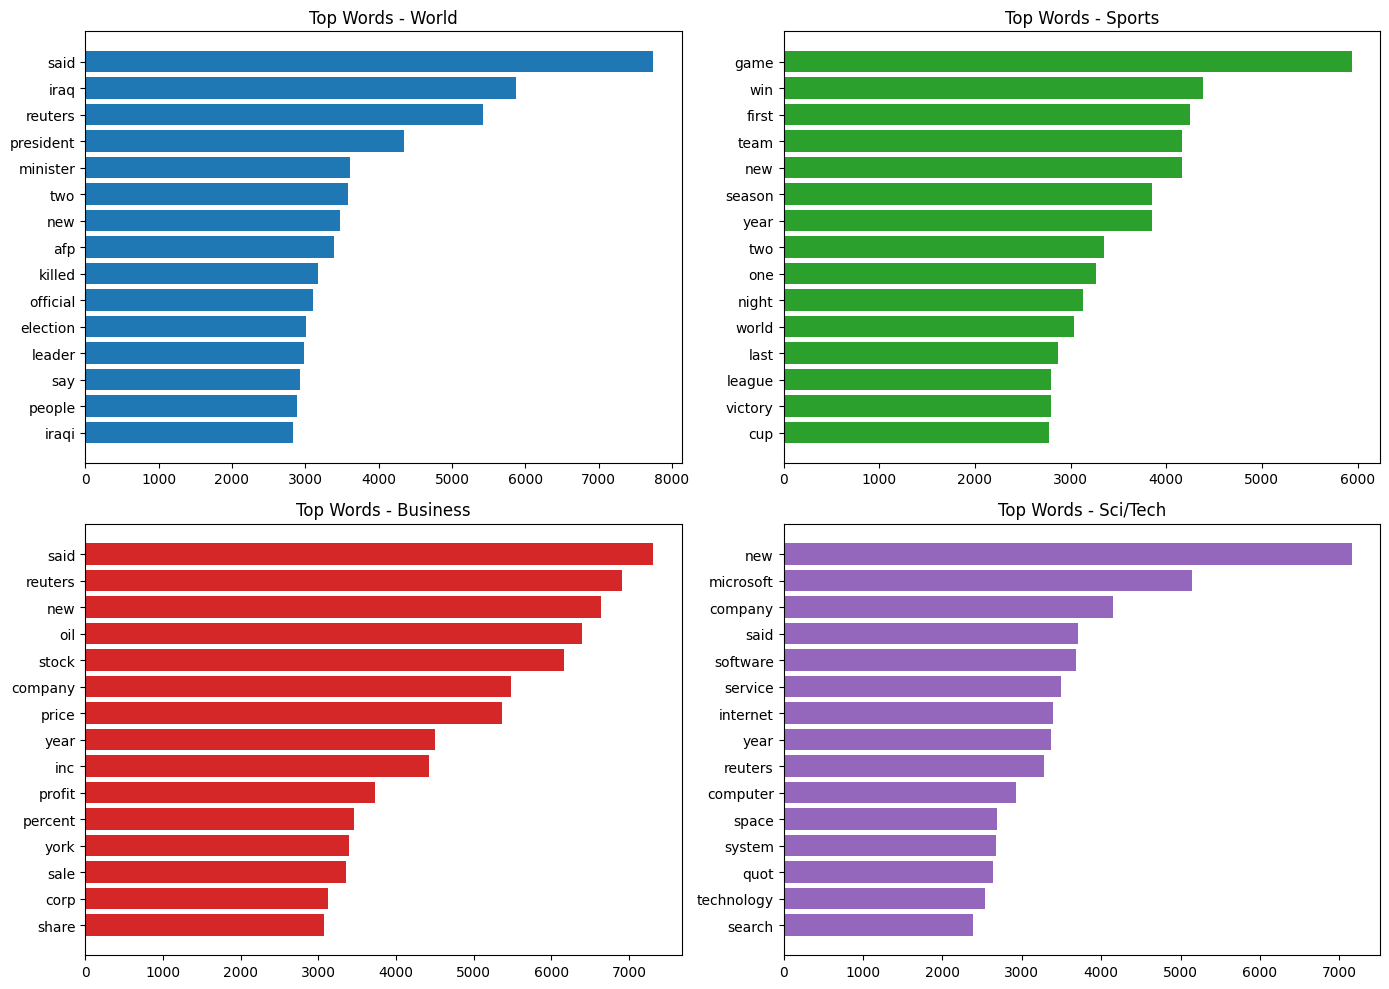

In [11]:
def top_words(text_series, n=15):
    all_words = " ".join(text_series).split()
    return Counter(all_words).most_common(n)

categories = ['World', 'Sports', 'Business', 'Sci/Tech']
colors = ['#1f77b4', '#2ca02c', '#d62728', '#9467bd']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, cat in enumerate(categories):
    words = top_words(train_df[train_df['category'] == cat]['clean_text'])
    axes[i].barh([w for w, c in words[::-1]], [c for w, c in words[::-1]], color=colors[i])
    axes[i].set_title(f"Top Words - {cat}")

plt.tight_layout()
plt.show()

##Word Clouds per category

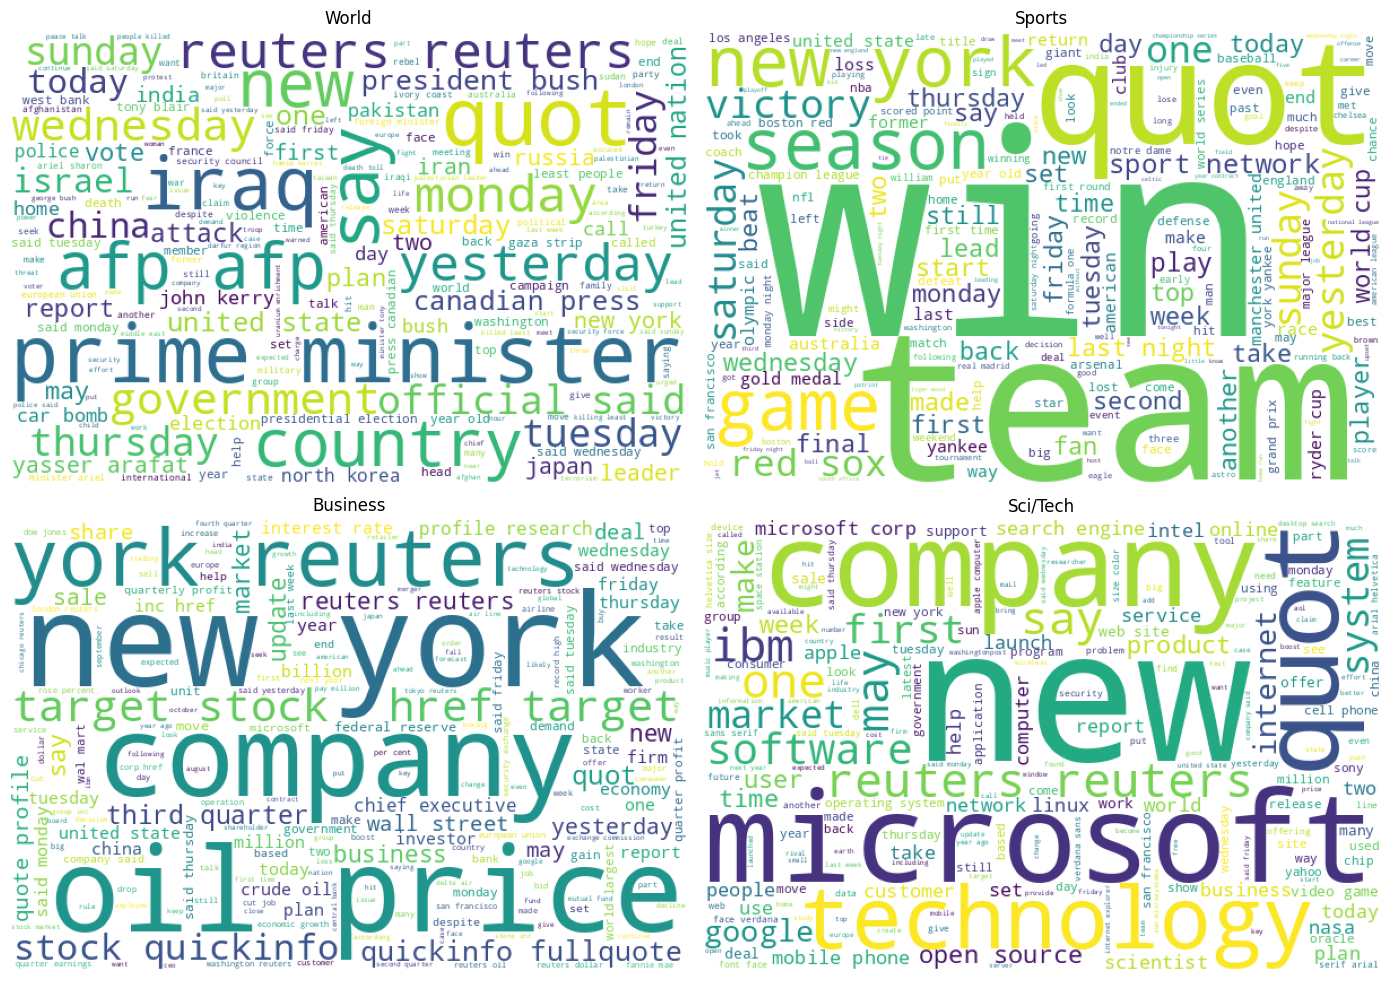

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, cat in enumerate(categories):
    text = " ".join(train_df[train_df['category'] == cat]['clean_text'])
    wc = WordCloud(width=600, height=400, background_color='white').generate(text)
    axes[i].imshow(wc)
    axes[i].axis('off')
    axes[i].set_title(cat)

plt.tight_layout()
plt.show()

##Feedforward Neural Network with Keras
Instead of TF-IDF (converting it to a dense array would use a huge amount of memory with 108k rows), we use a representation better suited to a neural network:
- `Tokenizer` maps each word to an integer index.
- `pad_sequences` makes every sequence the same length (padding/truncating at 40 tokens, which is plenty since the texts are short — title + description).
- An `Embedding` layer learns a dense vector representation for each word during training.
- `GlobalAveragePooling1D` averages the embeddings to turn each sentence into a single fixed-length vector (this is what keeps the architecture a "simple feedforward" network rather than an RNN/CNN).
- Two Dense layers at the end for classification.

In [13]:
MAX_WORDS = 30000
MAX_LEN = 40

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=MAX_LEN, padding='post', truncating='post')
X_val_seq = pad_sequences(tokenizer.texts_to_sequences(X_val), maxlen=MAX_LEN, padding='post', truncating='post')
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=MAX_LEN, padding='post', truncating='post')

label_to_id = {cat: i for i, cat in enumerate(categories)}
y_train_id = to_categorical(y_train.map(label_to_id), num_classes=4)
y_val_id = to_categorical(y_val.map(label_to_id), num_classes=4)
y_test_id = to_categorical(y_test.map(label_to_id), num_classes=4)

nn_model = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=128, input_length=MAX_LEN),
    GlobalAveragePooling1D(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(4, activation='softmax')
])

nn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
nn_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

##Train the neural network

In [14]:
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

history = nn_model.fit(
    X_train_seq, y_train_id,
    validation_data=(X_val_seq, y_val_id),
    epochs=15,
    batch_size=256,
    callbacks=[early_stop])

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.8483 - loss: 0.4503 - val_accuracy: 0.9149 - val_loss: 0.2509
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9268 - loss: 0.2250 - val_accuracy: 0.9195 - val_loss: 0.2414
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9412 - loss: 0.1783 - val_accuracy: 0.9177 - val_loss: 0.2422
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9501 - loss: 0.1462 - val_accuracy: 0.9155 - val_loss: 0.2729


##Evaluate the neural network on the test set

238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9143 - loss: 0.2586
Neural Network Test Accuracy: 0.9143421053886414
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

    Business       0.91      0.85      0.88      1900
    Sci/Tech       0.86      0.93      0.89      1900
      Sports       0.96      0.98      0.97      1900
       World       0.94      0.90      0.92      1900

    accuracy                           0.91      7600
   macro avg       0.92      0.91      0.91      7600
weighted avg       0.92      0.91      0.91      7600



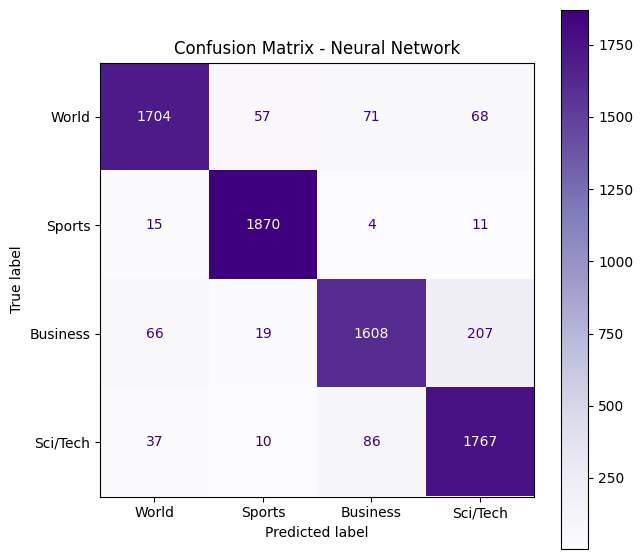

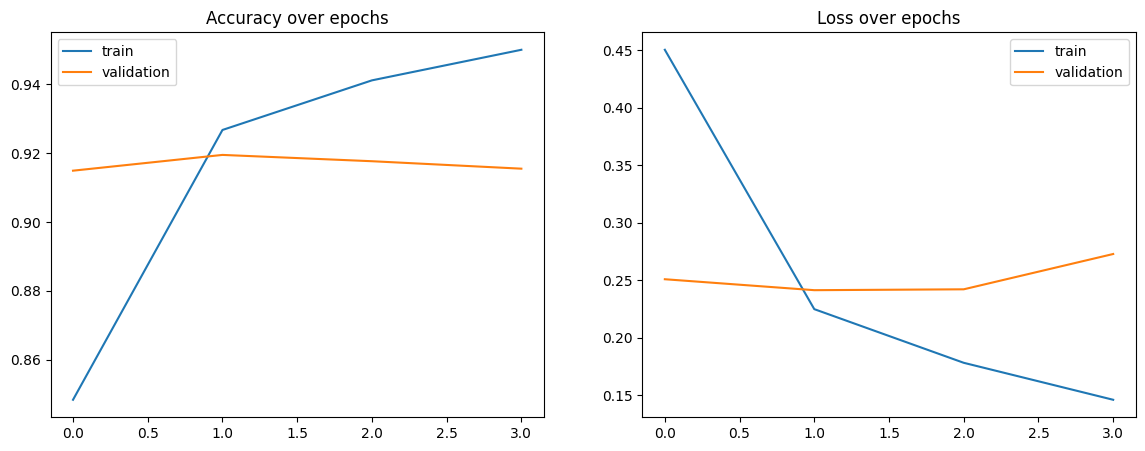

In [15]:
nn_test_loss, nn_test_acc = nn_model.evaluate(X_test_seq, y_test_id)
print("Neural Network Test Accuracy:", nn_test_acc)

y_pred_nn_probs = nn_model.predict(X_test_seq)
y_pred_nn = [categories[i] for i in np.argmax(y_pred_nn_probs, axis=1)]

print(classification_report(y_test, y_pred_nn))

cm_nn = confusion_matrix(y_test, y_pred_nn, labels=labels)
disp_nn = ConfusionMatrixDisplay(confusion_matrix=cm_nn, display_labels=labels)
fig, ax = plt.subplots(figsize=(7, 7))
disp_nn.plot(cmap='Purples', ax=ax)
plt.title("Confusion Matrix - Neural Network")
plt.show()

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['accuracy'], label='train')
axes[0].plot(history.history['val_accuracy'], label='validation')
axes[0].set_title("Accuracy over epochs")
axes[0].legend()

axes[1].plot(history.history['loss'], label='train')
axes[1].plot(history.history['val_loss'], label='validation')
axes[1].set_title("Loss over epochs")
axes[1].legend()
plt.show()

##Final comparison
Final comparison across all models on the test set.

In [16]:
print("=== Final Model Comparison (Test Accuracy) ===")
print(f"Linear SVM          : {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"Logistic Regression : {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Random Forest        : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Neural Network (Keras): {nn_test_acc:.4f}")

=== Final Model Comparison (Test Accuracy) ===
Linear SVM          : 0.9199
Logistic Regression : 0.9153
Random Forest        : 0.8975
Neural Network (Keras): 0.9143
